En este notebook se va a realizar el cambio de nombres de columnas, la obtención de la mediciónd de las elevaciones del Sol para 2024 y añadri la columna de año para 2024 para que ambos datasets tengan las mismas columnas.

Estos datasets transformados serán guardados en la carpeta data/interim para su uso en posteriores análisis

In [1]:
# importar datasets
import pandas as pd

df_2023 = pd.read_excel("../data/raw/datos_2023.xlsx")
df_2024 = pd.read_excel("../data/raw/datos_2024.xlsx")
df_alturas_2023 = pd.read_excel("../data/raw/alturas_2023.xlsx")

Comenzamos con los datos de 2023

In [2]:
df_2023.columns

Index(['Ano', 'Mes', 'Dia', 'Hora', 'Minuto', 'Fecha', 'GHI', 'DNI', 'DHI',
       'Temperatura [°C]', 'Velocidad del viento [m/s]',
       'Direccion del viento [º]', 'Humedad Relativa [%]', 'Codigo GHI',
       'Codigo DNI', 'Codigo dHI'],
      dtype='str')

In [3]:
column_mapping= {
    "Ano": "ano",
    "Mes": "mes",
    "Dia": "dia",
    "Hora": "hora",
    "Minuto": "minuto",
    "Fecha": "fecha",
    "DNI": "dni",
    "GHI": "ghi",
    "DHI": "dhi",
    "Temperatura [°C]": "temperatura",
    "Velocidad del viento [m/s]": "velocidad_viento",
    "Direccion del viento [º]": "direccion_viento",
    "Humedad Relativa [%]": "humedad_relativa",
    "Codigo GHI": "codigo_ghi",
    "Codigo DNI": "codigo_dni",
    "Codigo dHI": "codigo_dhi"
}

df_2023.rename(columns=column_mapping, inplace=True)
df_2023.head()

,ano,mes,dia,hora,minuto,fecha,ghi,dni,dhi,temperatura,velocidad_viento,direccion_viento,humedad_relativa,codigo_ghi,codigo_dni,codigo_dhi
0,2023,1,1,0,0,2023-01-01 00:00:00,0.0,0.0,0.0,10.0,1.050,117.750,77.0,0,0,0
1,2023,1,1,0,1,2023-01-01 00:01:00,0.0,0.0,0.0,10.0,1.333,311.500,77.0,0,0,0
2,2023,1,1,0,2,2023-01-01 00:02:00,0.0,0.0,0.0,10.0,1.100,256.417,77.0,0,0,0
3,2023,1,1,0,3,2023-01-01 00:03:00,0.0,0.0,0.0,10.0,1.333,290.417,77.0,0,0,0
4,2023,1,1,0,4,2023-01-01 00:04:00,0.0,0.0,0.0,10.0,1.058,333.667,77.0,0,0,0


In [4]:
df_2024.rename(columns=column_mapping, inplace=True)
df_2024.insert(0, "ano", 2024)
df_2024.head()

,ano,mes,dia,hora,minuto,fecha,ghi,dni,dhi,temperatura,velocidad_viento,direccion_viento,humedad_relativa,codigo_ghi,codigo_dni,codigo_dhi
0,2024,1,1,0,0,2024-01-01 00:00:00,0.0,0.0,0.0,9.2,0.925,312.167,92.000,0,0,0
1,2024,1,1,0,1,2024-01-01 00:01:00,0.0,0.0,0.0,9.2,1.125,310.833,92.167,0,0,0
2,2024,1,1,0,2,2024-01-01 00:02:00,0.0,0.0,0.0,9.2,1.233,304.333,92.417,0,0,0
3,2024,1,1,0,3,2024-01-01 00:03:00,0.0,0.0,0.0,9.2,1.083,313.500,92.000,0,0,0
4,2024,1,1,0,4,2024-01-01 00:04:00,0.0,0.0,0.0,9.2,1.050,311.000,92.333,0,0,0


Una vez cambiado el nombre de las columnas, se guardan en formato parquet para reducir el espacio y mejorar la eficiencia

In [5]:
from pathlib import Path

INTERIM_PATH = Path("../data/interim")
INTERIM_PATH.mkdir(parents=True, exist_ok=True)

df_2023.to_parquet(INTERIM_PATH / "datos_2023_standardized.parquet", index=False)
df_2024.to_parquet(INTERIM_PATH / "datos_2024_standardized.parquet", index=False)

Pasamos ahora a generar el dataset de las elevaciones solares para ambos años. Ahora mismo solo se tienen las elevaciones del año 2023 por lo que se tendrá que generar el de 2024.

Para el caso de 2023, se cambia la columna 'altura' por 'elevacion_solar' ya que realmente mide la elevación solar en grados y no en metros

In [39]:
df_alturas_2023.head()

,fecha,ano,mes,dia,hora,minuto,elevacion_solar
0,2023-01-01 00:00:00,2023,1.0,1,0,0,0.0
1,2023-01-01 00:01:00,2023,1.0,1,0,1,0.0
2,2023-01-01 00:02:00,2023,1.0,1,0,2,0.0
3,2023-01-01 00:03:00,2023,1.0,1,0,3,0.0
4,2023-01-01 00:04:00,2023,1.0,1,0,4,0.0


In [ ]:
column_mapping.update({
    'Año': 'ano',
    'Min': 'minuto',
    'altura': 'elevacion_solar'
})

df_alturas_2023.rename(columns=column_mapping, inplace=True)
df_alturas_2023.head()

,fecha,ano,mes,dia,hora,minuto,elevacion_solar
525596,2023-12-31 23:56:00,2023,12.0,365,23,56,0.0
525597,2023-12-31 23:57:00,2023,12.0,365,23,57,0.0
525598,2023-12-31 23:58:00,2023,12.0,365,23,58,0.0
525599,2023-12-31 23:59:00,2023,12.0,365,23,59,0.0
525600,2024-01-01 00:00:00,2023,NaN,365,24,0,NaN


In [41]:
df_alturas_2023.to_parquet(INTERIM_PATH / "elevacion_2023_standardized.parquet", index=False)

Generamos ahora los datos para 2024

In [ ]:
from pvlib.location import Location

# Datos de la estación meteorológica de Sevilla
LATITUDE = 37.41
LONGITUDE = -6.01       # Oeste se representa con signo negativo
ALTITUDE = 12           
TIMEZONE = "Europe/Madrid"

# Crear todos los minutos de 2024 en UTC. Para ello se comienza una hora menos que la hora local de Sevilla, que es UTC+1. 
# Esto es porque el método get_solarposition() requiere que los timestamps estén en UTC.
timestamps_utc = pd.date_range(
    start="2023-12-31 23:00:00",
    end="2024-12-31 23:00:00",
    freq="1min",
    inclusive="left",
    tz="UTC"
)

station = Location(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    tz=TIMEZONE,
    altitude=ALTITUDE,
    name="Estacion_Sevilla"
)

solar_position = station.get_solarposition(
    times=timestamps_utc,
    method="nrel_numpy"
)

df_solar_2024 = (
    solar_position[
        [
            "elevation",
            "apparent_elevation"
        ]
    ]
    .rename_axis("timestamp_utc")
    .reset_index()
)

# Fecha y hora local, manteniendo correctamente el cambio de hora
df_solar_2024["timestamp_local"] = (
    df_solar_2024["timestamp_utc"]
    .dt.tz_convert(TIMEZONE)
)

df_solar_2024.head()

,timestamp_utc,elevation,apparent_elevation,timestamp_local,date_local,time_local
0,2023-12-31 23:00:00+00:00,-66.443870,-66.443870,2024-01-01 00:00:00+01:00,2024-01-01,00:00:00
1,2023-12-31 23:01:00+00:00,-66.613003,-66.613003,2024-01-01 00:01:00+01:00,2024-01-01,00:01:00
2,2023-12-31 23:02:00+00:00,-66.781419,-66.781419,2024-01-01 00:02:00+01:00,2024-01-01,00:02:00
3,2023-12-31 23:03:00+00:00,-66.949101,-66.949101,2024-01-01 00:03:00+01:00,2024-01-01,00:03:00
4,2023-12-31 23:04:00+00:00,-67.116032,-67.116032,2024-01-01 00:04:00+01:00,2024-01-01,00:04:00


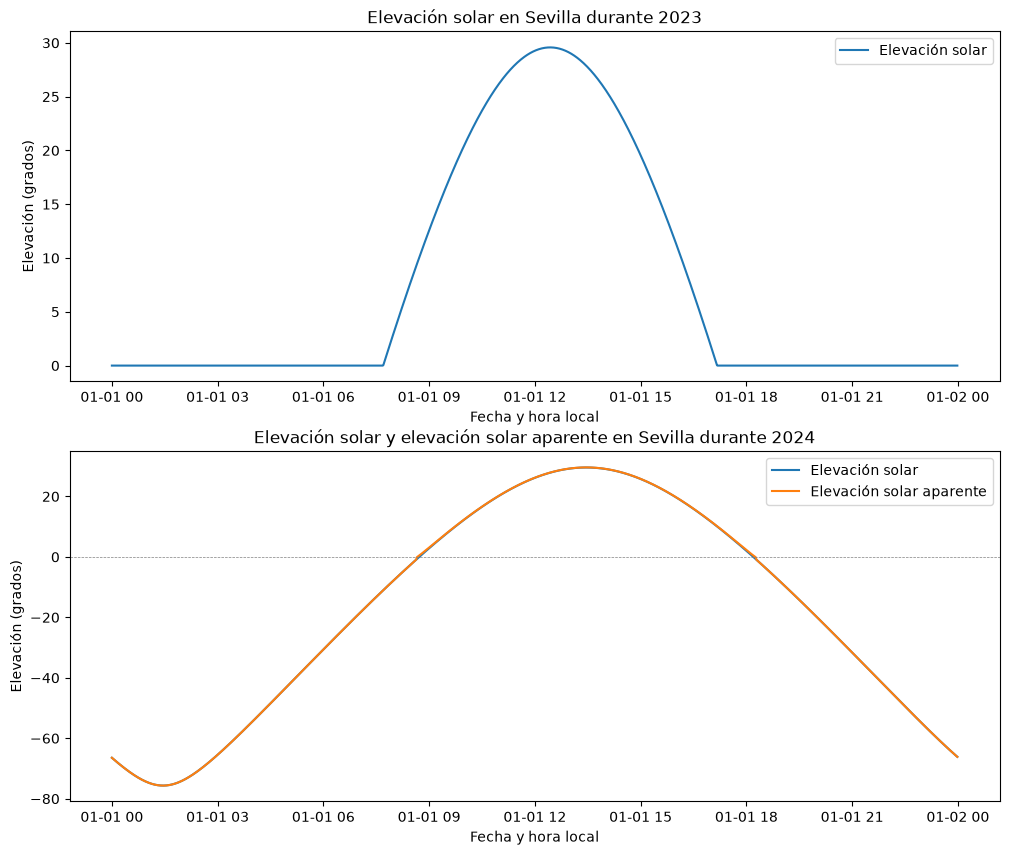

In [59]:
import matplotlib.pyplot as plt

primero_enero_2023 = df_alturas_2023[df_alturas_2023["fecha"].dt.date == pd.to_datetime("2023-01-01").date()]
primero_enero_2024 = df_solar_2024[df_solar_2024["date_local"] == pd.to_datetime("2024-01-01").date()]

plt.figure(figsize=(12, 10))
plt.subplot(2,1,1)
plt.plot(primero_enero_2023["fecha"], primero_enero_2023['elevacion_solar'], label="Elevación solar")
plt.title("Elevación solar en Sevilla durante 2023")
plt.xlabel("Fecha y hora local")
plt.ylabel("Elevación (grados)")
plt.legend()

plt.subplot(2,1,2)
plt.plot(primero_enero_2024["timestamp_local"], primero_enero_2024["elevation"], label="Elevación solar")
plt.plot(primero_enero_2024["timestamp_local"], primero_enero_2024["apparent_elevation"], label="Elevación solar aparente")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.title("Elevación solar y elevación solar aparente en Sevilla durante 2024")
plt.xlabel("Fecha y hora local")
plt.ylabel("Elevación (grados)")
plt.legend()
plt.show()


Podemos ver que en los datos dados de 2023 se ha decidido pasar a un valor de 0 todos los valores negativos, correspondientes a la noche, ya que en ese momento no se mide irradancia de ningún tipo. 

Además, se sabe que los datos dados de 2023 vienen de la [estación meteorológica de GTER](https://estacionmeteo.us.gter.es/) cuyo sensor óptico sigue la posición visible del Sol, es decir, la posición afectada por la refracción atmosférica, lo que corresponde con la medida de apparent_elevation obtenida anteriormente ya que mide la elevación solar aparente, corregida por refracción. 

De esta manera obtenemos el dataset de 2024 de alturas, obteniendo las mismas columnas que se tienen para el caso de 2023

In [72]:
df_alturas_2024 = df_solar_2024[['timestamp_local', 'apparent_elevation']].copy()

timestamps_utc = pd.date_range(
    start="2024-01-01 00:00:00",
    end="2024-12-31 23:59:00",
    freq="1min",
    tz="UTC"
)

df_alturas_2024 = pd.DataFrame({
    "fecha": timestamps_utc.tz_localize(None),
    "elevacion_solar": df_solar_2024["apparent_elevation"].clip(lower=0)
})

df_alturas_2024['ano'] = df_alturas_2024['fecha'].dt.year
df_alturas_2024['mes'] = df_alturas_2024['fecha'].dt.month
df_alturas_2024['dia'] = df_alturas_2024['fecha'].dt.dayofyear
df_alturas_2024['hora'] = df_alturas_2024['fecha'].dt.hour
df_alturas_2024['minuto'] = df_alturas_2024['fecha'].dt.minute

orden_columnas = df_alturas_2023.columns.tolist()
df_alturas_2024 = df_alturas_2024[orden_columnas]

df_alturas_2024.head()

,fecha,ano,mes,dia,hora,minuto,elevacion_solar
0,2024-01-01 00:00:00,2024,1,1,0,0,0.0
1,2024-01-01 00:01:00,2024,1,1,0,1,0.0
2,2024-01-01 00:02:00,2024,1,1,0,2,0.0
3,2024-01-01 00:03:00,2024,1,1,0,3,0.0
4,2024-01-01 00:04:00,2024,1,1,0,4,0.0


In [73]:
df_alturas_2024.info()

<class 'pandas.DataFrame'>
RangeIndex: 527040 entries, 0 to 527039
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   fecha            527040 non-null  datetime64[us]
 1   ano              527040 non-null  int32         
 2   mes              527040 non-null  int32         
 3   dia              527040 non-null  int32         
 4   hora             527040 non-null  int32         
 5   minuto           527040 non-null  int32         
 6   elevacion_solar  527040 non-null  float64       
dtypes: datetime64[us](1), float64(1), int32(5)
memory usage: 18.1 MB


In [74]:
print("Duplicados fecha:", df_alturas_2024['fecha'].duplicated().sum())
print("Dataset de alturas ordenado:", df_alturas_2024['fecha'].is_monotonic_increasing)

Duplicados fecha: 0
Dataset de alturas ordenado: True


In [67]:
df_alturas_2024.to_parquet(INTERIM_PATH / "elevacion_2024_standardized.parquet", index=False)

Ahora integramos las mediciones con las elevaciones

In [75]:
df_2023_integrated = df_2023.merge(
    df_alturas_2023[["fecha", "elevacion_solar"]],
    on="fecha",
    how="left",
    validate="one_to_one"
)

df_2024_integrated = df_2024.merge(
    df_alturas_2024[["fecha", "elevacion_solar"]],
    on="fecha",
    how="left",
    validate="one_to_one"
)

In [76]:
assert df_2023_integrated["elevacion_solar"].notna().all()
assert df_2024_integrated["elevacion_solar"].notna().all()

Y concatenamos ambos años

In [77]:
df_all = (
    pd.concat(
        [df_2023_integrated, df_2024_integrated],
        ignore_index=True
    )
    .sort_values("fecha")
    .reset_index(drop=True)
)

df_all.to_parquet(
    "../data/processed/dataset_solar_2023_2024_v1.parquet",
    index=False
)